# Forward Ising: sampling and team auto-completion

Companion to `inverse_ising.ipynb`. There we recovered the Ising parameters `(J, h)` from the chaos data; here we run the model *forwards* to sample team compositions and to build a team auto-completer that fills out a partial team given fixed members.

**The team-size constraint**. VGC teams have exactly 6 Pokémon. Single-spin flips violate `sum(s) = 6`, so we use **swap-move Metropolis-Hastings**: each step proposes turning one currently-on mon off and one currently-off mon on simultaneously. The proposal preserves team size by construction; the MH acceptance ratio is the standard `min(1, exp(-ΔH / T))` on the energy diff of the combined move.

**Energy diff for a swap** (turn off `i_out`, turn on `i_in`):

$$\Delta H = h_{i_{\text{out}}} - h_{i_{\text{in}}} + (J_{i_{\text{out}}} - J_{i_{\text{in}}}) \cdot s + J_{i_{\text{in}},\, i_{\text{out}}}$$

where `s` is the state before the swap. The last term corrects for the `i_in`/`i_out` coupling, which shouldn't be counted since they're being flipped simultaneously.

In [30]:
import numpy as np
import matplotlib.pyplot as plt

from k2dex import helpers

DATA_PATH = "gen9championsvgc2026regma-1760.json"
TEAM_SIZE = 6
EPS = 0.01
RNG_SEED = 0

chaos = helpers.load_chaos(DATA_PATH)
vocab = helpers.build_vocab(chaos, min_usage=0.002)
C = helpers.build_cooccurrence(chaos, vocab)
n = len(vocab)

m, p_joint = helpers.binary_moments(chaos, vocab, C, team_size=TEAM_SIZE)
Corr = helpers.binary_correlation(m, p_joint)
J, _ = helpers.ising_gaussian(Corr, eps=EPS)
h = np.log(m / (1 - m)) - J @ m

name_to_idx = {name: i for i, name in enumerate(vocab)}

print(f"metagame: {chaos.metagame}")
print(f"vocab:    {n}")
print(f"J range:  [{J.min():.3f}, {J.max():.3f}]")
print(f"h range:  [{h.min():.3f}, {h.max():.3f}]")

metagame: gen9championsvgc2026regma
vocab:    170
J range:  [-0.561, 1.005]
h range:  [-6.128, 0.108]


## Swap-move MCMC sampler

The core primitive: given Ising parameters `(J, h)`, a fixed set of nodes pinned at `s=1`, and a target team size, run swap-move Metropolis-Hastings. Returns the full trajectory of states for downstream aggregation (marginals, etc.).

Implementation detail: we maintain `on_nf` / `off_nf` (currently-on and currently-off *non-fixed* indices) as lists so each step is O(1) to pick a swap candidate; the energy diff is O(n) per step. At n=170, ~150k steps/sec on a single thread.

In [31]:
from k2dex.sampling import swap_mcmc

samples, accept = swap_mcmc(
    J, h, team_size=TEAM_SIZE, fixed=[], excluded=[],
    field_weight=1.0, n_steps=10000, temperature=1.0, seed=RNG_SEED,
)
print(f"10k steps complete: acceptance rate = {accept:.2%}, team sizes seen = {set(samples.sum(axis=1).tolist())}")

10k steps complete: acceptance rate = 27.55%, team sizes seen = {6}


## Calibration check: do forward marginals recover empirical `m`?

Before trusting the model for completions, verify that the unconstrained (no `fixed`) forward sampler approximately reproduces the data's per-Pokémon marginals. If sampled marginals match `m`, the inverse fit faithfully captured the data and the auto-completer can be trusted. If they don't, predictions will be biased the same way.

Run a long chain at T=1, drop burn-in, compare per-mon marginal occupancy to empirical `m`. Also sweep temperature in case a global rescaling improves fit.

T=1.0:  RMSE(sample_m, m) = 0.0078, corr = 0.9938


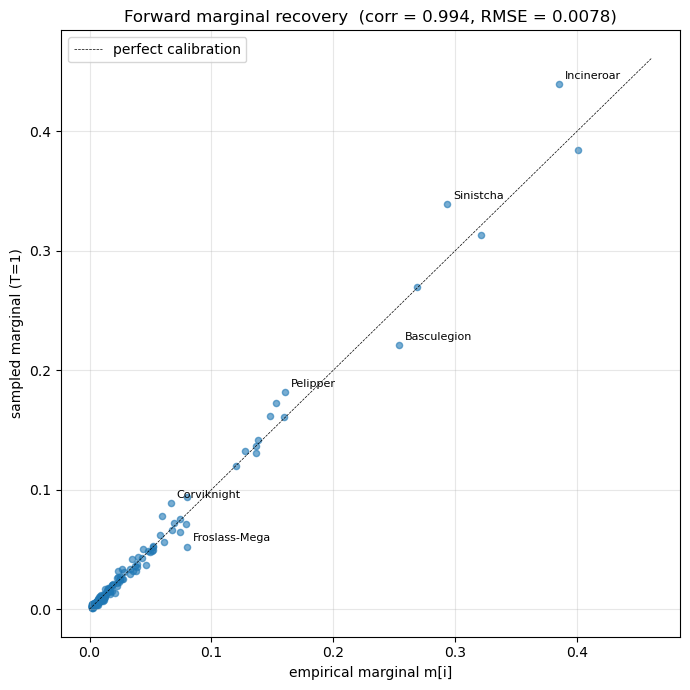


Temperature sweep (effective T = sampling temperature, lower = stronger interactions):
  T= 0.5: RMSE=0.0565, corr=0.9596
  T=0.75: RMSE=0.0271, corr=0.9725
  T= 1.0: RMSE=0.0138, corr=0.9789
  T=1.25: RMSE=0.0180, corr=0.9777
  T= 1.5: RMSE=0.0260, corr=0.9564
  T= 2.0: RMSE=0.0390, corr=0.9156


In [32]:
burn_in = 5000
n_steps_calib = 50000

samples, _ = swap_mcmc(J, h, n_steps=n_steps_calib, temperature=1.0, seed=RNG_SEED)
sample_m = samples[burn_in:].mean(axis=0)

rmse = np.sqrt(((sample_m - m) ** 2).mean())
corr = np.corrcoef(sample_m, m)[0, 1]
print(f"T=1.0:  RMSE(sample_m, m) = {rmse:.4f}, corr = {corr:.4f}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(m, sample_m, s=20, alpha=0.6)
lim = max(m.max(), sample_m.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=0.5, label="perfect calibration")
for i in np.argsort(-np.abs(sample_m - m))[:6]:
    ax.annotate(vocab[i], (m[i], sample_m[i]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set(xlabel="empirical marginal m[i]", ylabel="sampled marginal (T=1)",
       title=f"Forward marginal recovery  (corr = {corr:.3f}, RMSE = {rmse:.4f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Temperature sweep — does scaling J, h improve fit?
print("\nTemperature sweep (effective T = sampling temperature, lower = stronger interactions):")
for T in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    s, _ = swap_mcmc(J, h, n_steps=15000, temperature=T, seed=RNG_SEED)
    sm = s[3000:].mean(axis=0)
    r = np.sqrt(((sm - m) ** 2).mean())
    c = np.corrcoef(sm, m)[0, 1]
    print(f"  T={T:>4}: RMSE={r:.4f}, corr={c:.4f}")

## Team auto-completer

Three knobs:

- **`fixed_names`** — Pokémon that must appear in the completed team.
- **`excluded_names`** — Pokémon that must NOT appear.
- **`field_weight`** — scales the field `h` before sampling. **This is the critical knob for archetype-coherent completions.**

### Why `field_weight` matters

The Ising energy is `H(s) = -h·s - ½ s'Js`. Two competing forces:

- **`h`** spans roughly `[-6, 0]` because it's calibrated to reproduce empirical marginals (`m` spans 0.3% to 40%, so `logit(m)` spans about 6 units).
- **`J`** is much smaller in magnitude — pairwise correlations are bounded, and the strongest coupling (`Pelipper / Archaludon`) is around `+1.0`. Most positive `J` values are in `[0.05, 0.3]`.

This means `h` dominates the energy. When we condition on `Farigiraf + Golurk-Mega`, the strongest pairwise pull (`+J` with Torkoal at ~0.55 combined) is smaller than the `h`-gap between Sneasler (`h ≈ 0`) and Torkoal (`h ≈ -2.4`). So **Sneasler wins on energy** despite being uncoupled to the fixed mons. That's the structural reason completions look meta-centric.

**`field_weight = 0` drops `h` entirely.** The model becomes `P(s) ∝ exp(½ s'Js)` — the MaxEnt distribution with observed pairwise constraints but a uniform first-order prior. No popularity bias. Pairwise synergy is the only force shaping the energy, so conditioning on TR setters surfaces other TR mons.

Intermediate values smoothly interpolate. Combined with low temperature (`T ≈ 0.02–0.05`) the pure-pairwise mode concentrates on archetype-coherent modes; the default-calibrated mode (`field_weight=1.0`) needs higher T for diversity but always trends meta-centric.

### Two modes

- **`complete_distribution`** — multi-chain sampling, returns sorted distribution over completions.
- **`complete_anneal`** — single chain with cooling schedule, returns the single MAP completion.

Both take `field_weight` and `temperature` independently.

In [33]:
def complete_distribution(
    fixed_names: list[str],
    excluded_names: list[str] | None = None,
    field_weight: float = 1.0,
    n_chains: int = 20,
    n_steps: int = 8000,
    burn_in: int = 2000,
    temperature: float = 0.1,
    seed: int = 0,
) -> list[tuple[tuple[int, ...], float]]:
    """Sample the distribution over team completions given fixed/excluded sets.

    field_weight scales h: 1.0 = data-calibrated, 0.0 = pure pairwise (no popularity prior).
    Use field_weight < 1 with low temperature (T ~ 0.02-0.1) for archetype-coherent
    completions; high field_weight with moderate temperature for posterior-faithful samples.
    """
    rng_master = np.random.default_rng(seed)
    fixed_idx = sorted({name_to_idx[name] for name in fixed_names})
    excluded_idx = sorted({name_to_idx[name] for name in (excluded_names or [])})
    fixed_set = set(fixed_idx)
    counts: dict[tuple[int, ...], int] = {}
    n_kept = 0
    for _ in range(n_chains):
        chain_seed = int(rng_master.integers(2**31))
        s, _ = swap_mcmc(J, h, team_size=TEAM_SIZE, fixed=fixed_idx, excluded=excluded_idx,
                         field_weight=field_weight, n_steps=n_steps,
                         temperature=temperature, seed=chain_seed)
        for state in s[burn_in:]:
            comp = tuple(sorted(int(i) for i in np.where(state)[0] if i not in fixed_set))
            counts[comp] = counts.get(comp, 0) + 1
            n_kept += 1
    return [(comp, cnt / n_kept) for comp, cnt in sorted(counts.items(), key=lambda x: -x[1])]


def complete_anneal(
    fixed_names: list[str],
    excluded_names: list[str] | None = None,
    field_weight: float = 1.0,
    n_steps: int = 20000,
    t_start: float = 3.0,
    t_end: float = 0.02,
    seed: int = 0,
) -> np.ndarray:
    """Anneal from t_start to t_end (exponential schedule), return final state."""
    rng = np.random.default_rng(seed)
    fixed_idx = sorted({name_to_idx[name] for name in fixed_names})
    excluded_idx = sorted({name_to_idx[name] for name in (excluded_names or [])})
    fixed_set = set(fixed_idx)
    excluded_set = set(excluded_idx)
    h_eff = field_weight * h

    state = np.zeros(n, dtype=bool)
    for i in fixed_idx:
        state[i] = True
    n_to_fill = TEAM_SIZE - len(fixed_set)
    available_pool = np.array([i for i in range(n) if i not in fixed_set and i not in excluded_set])
    init = rng.choice(available_pool, size=n_to_fill, replace=False)
    state[init] = True
    on_nf = list(init)
    off_nf = list(set(available_pool.tolist()) - set(init.tolist()))
    state_f = state.astype(np.float64)

    for step in range(n_steps):
        T = t_start * (t_end / t_start) ** (step / max(n_steps - 1, 1))
        out_k = rng.integers(len(on_nf))
        in_k = rng.integers(len(off_nf))
        i_out = on_nf[out_k]; i_in = off_nf[in_k]
        dH = h_eff[i_out] - h_eff[i_in] + np.dot(J[i_out] - J[i_in], state_f) + J[i_in, i_out]
        if dH <= 0 or rng.random() < np.exp(-dH / T):
            state[i_out] = False; state[i_in] = True
            state_f[i_out] = 0.0; state_f[i_in] = 1.0
            on_nf[out_k] = i_in; off_nf[in_k] = i_out
    return state


def report_completion(
    fixed_names: list[str],
    excluded_names: list[str] | None = None,
    field_weight: float = 1.0,
    temperature: float = 0.1,
    top_k: int = 10,
) -> None:
    header = f"=== fix: {', '.join(fixed_names)}"
    if excluded_names:
        header += f"  |  exclude: {', '.join(excluded_names)}"
    header += f"  |  field={field_weight}, T={temperature} ==="
    print(header + "\n")
    dist = complete_distribution(fixed_names, excluded_names=excluded_names,
                                  field_weight=field_weight,
                                  n_chains=20, n_steps=8000, burn_in=2000,
                                  temperature=temperature)
    print(f"sampled {len(dist)} distinct completions; top-{top_k} by probability:")
    for comp, p in dist[:top_k]:
        print(f"  {p:.4f}  {', '.join(vocab[i] for i in comp)}")
    print("\nbest single completion (annealing T: 3.0 -> 0.02):")
    best = complete_anneal(fixed_names, excluded_names=excluded_names,
                            field_weight=field_weight, n_steps=20000)
    fixed_set = {name_to_idx[name] for name in fixed_names}
    completion = sorted(vocab[i] for i in np.where(best)[0] if i not in fixed_set)
    print("  " + ", ".join(completion))
    print()

## Example completions

Pin Pokémon at `fixed_names` (must appear) and optionally at `excluded_names` (must not appear). Below: a couple of fixed-only examples, then the same first query with the universal-glue mons excluded — surfaces archetype-specific picks that the unconstrained sampler buries under universal hubs.

In [35]:
# Three views of the same Farigiraf + Golurk-Mega query:
#   1. Data-faithful posterior: shows what teams actually contain these mons in the data
#      (meta-biased — Sneasler/Incineroar dominate because they appear on most teams).
#   2. Excluding the universal hubs: shifts toward next-tier meta but still popularity-biased.
#   3. Pure pairwise (field_weight=0, low T): drops popularity prior entirely, surfaces
#      archetype-coherent completions driven only by J coupling.
report_completion(["Farigiraf", "Golurk-Mega"], field_weight=1.0, temperature=0.1, top_k=5)
report_completion(["Farigiraf", "Golurk-Mega"],
                  excluded_names=["Sneasler", "Incineroar"],
                  field_weight=1.0, temperature=0.1, top_k=5)
report_completion(["Farigiraf", "Golurk-Mega"], field_weight=0.0, temperature=0.02, top_k=5)

# Same comparison for the partial-team case
report_completion(["Froslass-Mega", "Sinistcha", "Aerodactyl"], field_weight=1.0, temperature=0.1, top_k=5)
report_completion(["Froslass-Mega", "Sinistcha", "Aerodactyl"], field_weight=0.2, temperature=0.05, top_k=5)

=== fix: Farigiraf, Golurk-Mega  |  field=1.0, T=0.1 ===

sampled 8 distinct completions; top-5 by probability:
  0.6224  Sneasler, Incineroar, Sinistcha, Kingambit
  0.1871  Sneasler, Incineroar, Garchomp, Sinistcha
  0.0924  Sneasler, Incineroar, Garchomp, Kingambit
  0.0530  Sneasler, Incineroar, Sinistcha, Basculegion
  0.0369  Sneasler, Incineroar, Kingambit, Basculegion

best single completion (annealing T: 3.0 -> 0.02):
  Incineroar, Kingambit, Sinistcha, Sneasler

=== fix: Farigiraf, Golurk-Mega  |  exclude: Sneasler, Incineroar  |  field=1.0, T=0.1 ===

sampled 20 distinct completions; top-5 by probability:
  0.6803  Garchomp, Sinistcha, Kingambit, Basculegion
  0.0897  Sinistcha, Basculegion, Pelipper, Archaludon
  0.0685  Kingambit, Basculegion, Pelipper, Archaludon
  0.0427  Sinistcha, Kingambit, Basculegion, Pelipper
  0.0188  Garchomp, Kingambit, Basculegion, Pelipper

best single completion (annealing T: 3.0 -> 0.02):
  Basculegion, Garchomp, Kingambit, Sinistcha

=== fi